<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/clustering%20techniques%20to%20group%20Kenyan%20regions%20based%20on%20factors%20like%20food%20production%2C%20income%20levels%2C%20and%20population%20density.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2 0.5
3 0.559
4 0.468
5 0.372
6 0.373


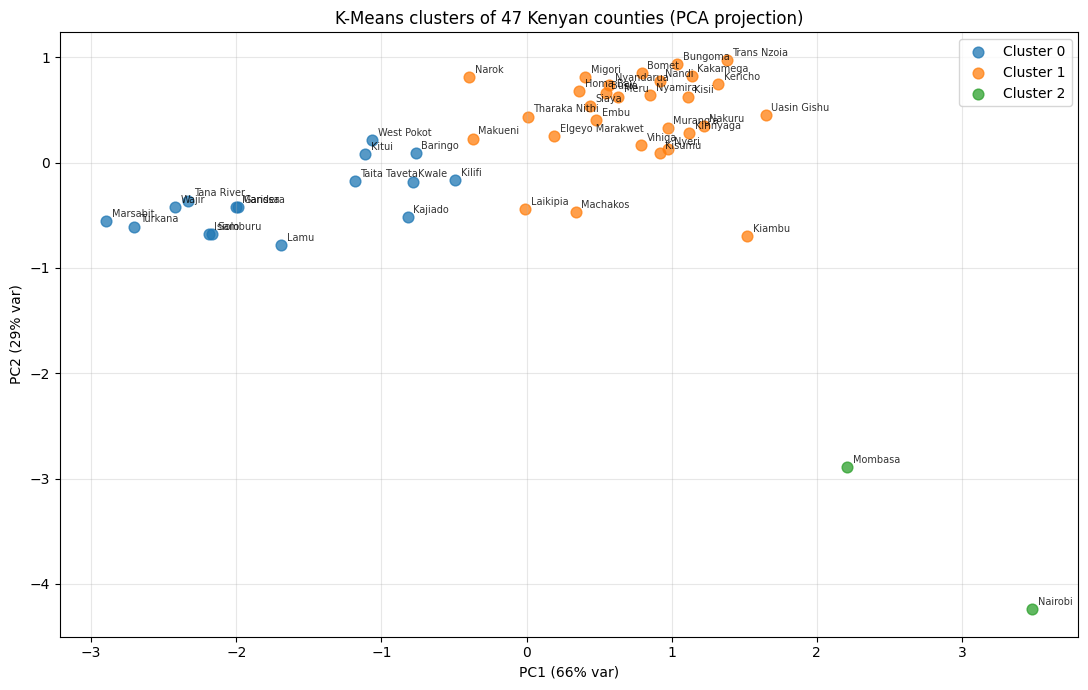

Cluster
0    Kwale, Kilifi, Tana River, Lamu, Taita Taveta,...
1    Meru, Tharaka Nithi, Embu, Machakos, Makueni, ...
2                                     Nairobi, Mombasa
Name: County, dtype: object
         PopDensity  Income  FoodProd
Cluster                              
0              25.0   145.0      24.0
1             364.0   210.0      74.0
2            5789.0   485.0      14.0


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

counties = ["Nairobi","Mombasa","Kwale","Kilifi","Tana River","Lamu","Taita Taveta",
 "Garissa","Wajir","Mandera","Marsabit","Isiolo","Meru","Tharaka Nithi","Embu","Kitui",
 "Machakos","Makueni","Nyandarua","Nyeri","Kirinyaga","Murang'a","Kiambu","Turkana",
 "West Pokot","Samburu","Trans Nzoia","Uasin Gishu","Elgeyo Marakwet","Nandi","Baringo",
 "Laikipia","Nakuru","Narok","Kajiado","Kericho","Bomet","Kakamega","Vihiga","Bungoma",
 "Busia","Siaya","Kisumu","Homa Bay","Migori","Kisii","Nyamira"]
density = [6317,5261,105,119,9,23,20,27,15,34,7,11,223,151,238,47,239,123,193,322,413,
 412,951,13,74,15,401,394,150,307,61,56,288,44,53,364,354,612,1048,548,549,393,554,359,
 433,962,674]                                  # persons/km2 (2019 census)
income  = [570,400,160,180,130,170,190,120,105,110,100,150,215,185,210,150,240,170,210,
 255,250,235,300,95,130,140,240,290,210,220,170,265,270,180,200,250,200,210,190,200,170,
 180,230,170,160,200,190]                      # GDP per capita, '000 KSh (approx.)
food    = [12,15,40,45,25,22,45,22,18,20,12,20,78,65,70,45,50,55,80,72,76,74,58,10,45,18,
 95,90,65,84,50,55,82,74,38,90,82,84,60,85,70,68,66,70,72,76,74]  # agri output index 0-100

df = pd.DataFrame({"County":counties, "PopDensity":density, "Income":income, "FoodProd":food})

# Preprocess: log-transform skewed density, standardize
X  = df.assign(LogD=np.log10(df.PopDensity))[["LogD","Income","FoodProd"]]
Xs = StandardScaler().fit_transform(X)

# Pick k
for k in range(2,7):
    print(k, round(silhouette_score(Xs, KMeans(k, n_init=10, random_state=42).fit_predict(Xs)),3))
# -> k = 3 typically best

df["Cluster"] = KMeans(3, n_init=10, random_state=42).fit_predict(Xs)

# ---- PCA scatter plot ----
pca = PCA(n_components=2, random_state=42)
Z, ev = pca.fit_transform(Xs), pca.explained_variance_ratio_
plt.figure(figsize=(11,7))
for c in sorted(df.Cluster.unique()):
    m = df.Cluster==c
    plt.scatter(Z[m,0], Z[m,1], label=f"Cluster {c}", s=60, alpha=.75)
for i,r in df.iterrows():
    plt.annotate(r.County, Z[i], fontsize=7, alpha=.8, xytext=(4,3), textcoords="offset points")
plt.xlabel(f"PC1 ({ev[0]:.0%} var)"); plt.ylabel(f"PC2 ({ev[1]:.0%} var)")
plt.title("K-Means clusters of 47 Kenyan counties (PCA projection)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

print(df.groupby("Cluster")["County"].apply(", ".join))
print(df.groupby("Cluster")[["PopDensity","Income","FoodProd"]].median().round(0))